### Задание 1
Найти и выгрузить многомерные данные (с большим количеством признаков – столбцов) с использованием библиотеки pandas. В отчёте описать найденные данные.

In [7]:
import pandas as pd

cpu = pd.read_csv('cpu.csv', sep=',')


### Задание 2
Вывести информацию о данных при помощи методов .info(), .head(). Проверить данные на наличие пустых значений. В случае их наличия удалить данные строки или интерполировать пропущенные значения. При необходимости дополнительно предобработать данные для дальнейшей работы с ними.

In [8]:
import pandas as pd

cpu = pd.read_csv('cpu.csv', sep=',')

cpu.head()

,Name,Codename,Cores,Clock,Socket,Process,L3 Cache,TDP,Released
0,\r\nRyzen 5 3600\r\n,Matisse,6 / 12,3.6 to 4.2 GHz,Socket AM4,7 nm,32MB,65 W,"Jul 7th, 2019"
1,\r\nRyzen 5 5600X\r\n,Vermeer,6 / 12,3.7 to 4.6 GHz,Socket AM4,7 nm,32MB,65 W,"Nov 5th, 2020"
2,\r\nRyzen 5 5600G\r\n,Cezanne,6 / 12,3.9 to 4.4 GHz,Socket AM4,7 nm,16MB,65 W,"Apr 13th, 2021"
3,\r\nA8-7680\r\n,Godaveri,4,3.5 to 3.8 GHz,Socket FM2+,28 nm,NaN,45 W,"Oct 26th, 2018"
4,\r\nCore i5-10400F\r\n,Comet Lake,6 / 12,2.9 to 4.3 GHz,Socket 1200,14 nm,12MB,65 W,"Apr 30th, 2020"


In [9]:
import pandas as pd

cpu = pd.read_csv('cpu.csv', sep=',')

cpu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      50 non-null     object
 1   Codename  50 non-null     object
 2   Cores     50 non-null     object
 3   Clock     50 non-null     object
 4   Socket    50 non-null     object
 5   Process   50 non-null     object
 6   L3 Cache  45 non-null     object
 7   TDP       50 non-null     object
 8   Released  50 non-null     object
dtypes: object(9)
memory usage: 3.6+ KB


### Задание 3
Построить столбчатую диаграмму (.bar) с использованием модуля graph_objs из библиотеки Plotly со следующими параметрами:
- По оси Х указать дату или название, по оси У указать количественный показатель.
- Сделать так, чтобы столбец принимал цвет в зависимости от значения показателя (marker=dict(color=признак, coloraxis="coloraxis")).
- Сделать так, чтобы границы каждого столбца были выделены чёрной линией с толщиной равной 2.
- Отобразить заголовок диаграммы, разместив его по центру сверху, с 20 размером текста.
- Добавить подписи для осей X и Y с размером текста, равным 16. Для оси абсцисс развернуть метки так, чтобы они читались под углом, равным 315.
- Размер текста меток осей сделать равным 14.
- Расположить график во всю ширину рабочей области и присвоить высоту, равную 700 пикселей.
- Добавить сетку на график, сделать её цвет 'ivory' и толщину равную 2. (Можно сделать это при настройке осей с помощью gridwidth=2, gridcolor='ivory')
- Убрать лишние отступы по краям.

In [10]:
import pandas as pd
import plotly.graph_objs as go

cpu = pd.read_csv('cpu.csv', sep=',')

# Преобразуем TDP к числовому виду
cpu['TDP_clean'] = cpu['TDP'].str.replace(" W", "", regex=False).astype(float)

# Строим столбчатую диаграмму
fig = go.Figure(data=[
    go.Bar(
        x=cpu['Name'],
        y=cpu['TDP_clean'],
        marker=dict(
            color=cpu['TDP_clean'],
            coloraxis="coloraxis",
            line=dict(color="black", width=2)
        )
    )
])

fig.update_layout(
    title=dict(text="Энергопотребление процессоров (TDP)", x=0.5, font=dict(size=20)),
    xaxis=dict(
        title=dict(text="Процессор", font=dict(size=16)),
        tickangle=315,
        tickfont=dict(size=14),
        showgrid=True,
        gridwidth=2,
        gridcolor="ivory"
    ),
    yaxis=dict(
        title=dict(text="TDP (Вт)", font=dict(size=16)),
        tickfont=dict(size=14),
        showgrid=True,
        gridwidth=2,
        gridcolor="ivory"
    ),
    coloraxis=dict(colorscale="Viridis"),
    height=700,
    autosize=True,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

### Задание 4
Построить круговую диаграмму (go.Pie), использовав данные и стиль оформления из предыдущего графика. Сделать так, чтобы границы каждой доли были выделены чёрной линией с толщиной, равной 2 и категории круговой диаграммы были читаемы (к примеру, объединить часть объектов)

In [11]:
import pandas as pd
import plotly.graph_objs as go

cpu = pd.read_csv('cpu.csv', sep=',')

cpu['TDP_clean'] = cpu['TDP'].str.replace(" W", "", regex=False).astype(float)

cpu_sorted = cpu.sort_values(by="TDP_clean", ascending=False)
top_n = 8
cpu_top = cpu_sorted.head(top_n).copy()
cpu_other = cpu_sorted.iloc[top_n:].copy()

if not cpu_other.empty:
    other_sum = cpu_other["TDP_clean"].sum()
    cpu_top = pd.concat([cpu_top, pd.DataFrame({"Name": ["Прочее"], "TDP_clean": [other_sum]})])

fig = go.Figure(data=[
    go.Pie(
        labels=cpu_top["Name"],
        values=cpu_top["TDP_clean"],
        textinfo="label+percent",
        marker=dict(
            line=dict(color="black", width=2)
        )
    )
])

fig.update_layout(
    title=dict(text="Распределение энергопотребления процессоров (TDP)",
               x=0.5, font=dict(size=20)),
    height=700,
    autosize=True,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()


### Задание 5
Построить линейные графики, взять один из параметров и определить зависимость между другими несколькими (от 2 до 5) показателями с использованием библиотеки matplotlib. Сделать вывод.
- Сделать график с линиями и маркерами, цвет линии 'crimson', цвет точек 'white', цвет границ точек 'black', толщина границ точек равна 2.
- Добавить сетку на график, сделать её цвет 'mistyrose' и толщину равную 2. (Можно сделать это при настройке осей с помощью linewidth=2, color='mistyrose').

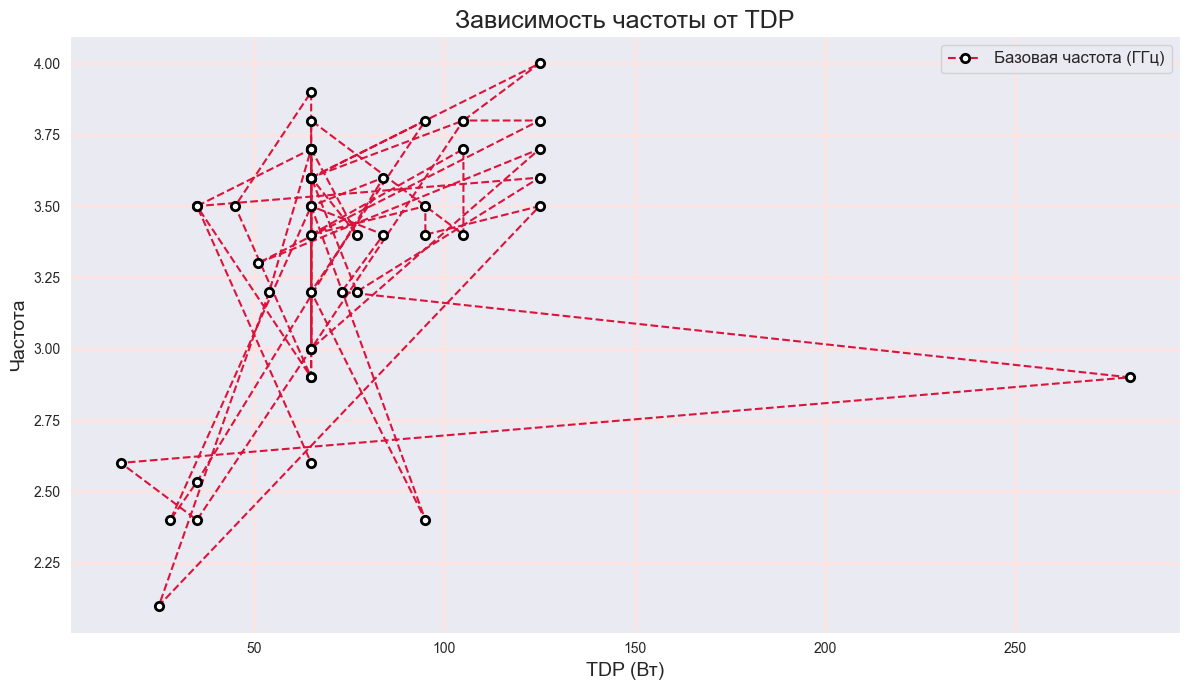

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

cpu = pd.read_csv('cpu.csv', sep=',')

cpu['TDP_clean'] = cpu['TDP'].str.replace(" W", "", regex=False).astype(float)

cpu['Clock_clean'] = (cpu['Clock'].astype(str).str.split("to").str[0].str.replace("GHz", "", regex=False).str.strip())
cpu['Clock_clean'] = pd.to_numeric(cpu['Clock_clean'], errors='coerce')

x = cpu['TDP_clean']
y = cpu['Clock_clean']

plt.figure(figsize=(12, 7))
plt.plot(x, y, marker='o', color='crimson', markerfacecolor='white', markeredgecolor='black', markeredgewidth=2,
         linestyle='--', label="Базовая частота (ГГц)")

plt.title("Зависимость частоты от TDP", fontsize=18)
plt.xlabel("TDP (Вт)", fontsize=14)
plt.ylabel("Частота", fontsize=14)
plt.grid(True, linewidth=2, color='mistyrose')
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()


### Задание 6
Выполнить визуализацию многомерных данных, используя t-SNE. Необходимо использовать набор данных MNIST или fashion MNIST (можно использовать и другие готовые наборы данных, где можно наблюдать разделение объектов по кластерам). Рассмотреть результаты визуализации для разных значений перплексии.

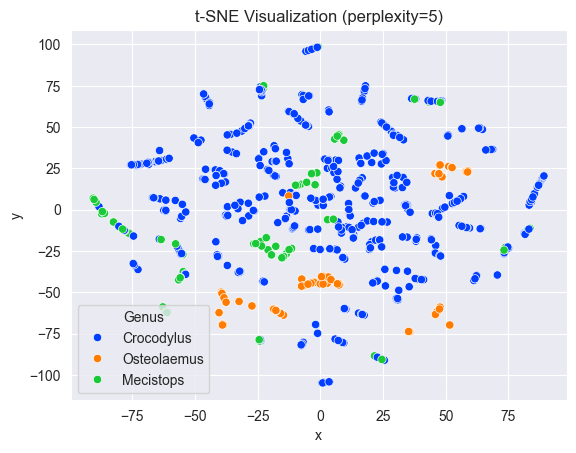

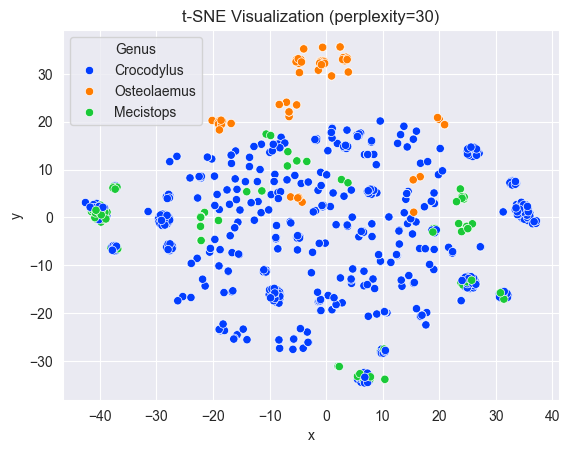

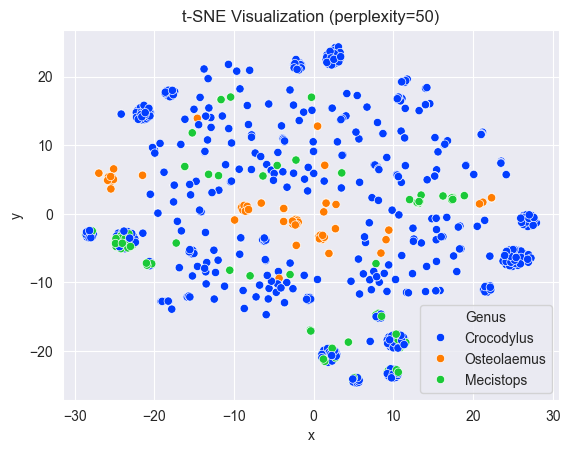

Time taken for t-SNE: 12.98 seconds


In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
import time

data = pd.read_csv("crocodile.csv")

features = ["Observed Length (m)", "Observed Weight (kg)", "Age Class", "Sex", "Habitat Type"]
D = pd.get_dummies(data[features], drop_first=True)

scaler = preprocessing.MinMaxScaler()
D = pd.DataFrame(scaler.fit_transform(D), columns=D.columns)

perplexities = [5, 30, 50]

start_time_umap = time.time()
for perp in perplexities:
    T = TSNE(n_components=2, perplexity=perp, random_state=123)
    TSNE_features = T.fit_transform(D)

    DATA = D.copy()
    DATA['x'] = TSNE_features[:,0]
    DATA['y'] = TSNE_features[:,1]

    plt.figure()
    sns.scatterplot(x='x', y='y', hue=data['Genus'], data=DATA, palette='bright')
    plt.title(f"t-SNE Visualization (perplexity={perp})")
    plt.show()
end_time_umap = time.time()
print(f"Time taken for t-SNE: {end_time_umap - start_time_umap:.2f} seconds")

### Задание 7
Выполнить визуализацию многомерных данных, используя UMAP с различными параметрами n_neighbors и min_dist. Рассчитать время работы алгоритма с помощью библиотеки time и сравнить его с временем работы t-SNE.

C:\Users\shilo\Documents\Git\Seventh semester\BigData\PythonProject\PR2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



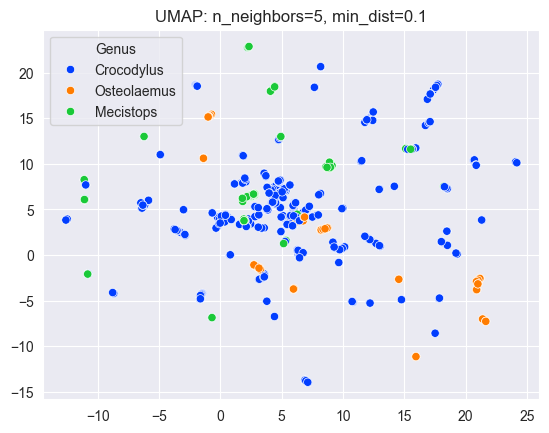

C:\Users\shilo\Documents\Git\Seventh semester\BigData\PythonProject\PR2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



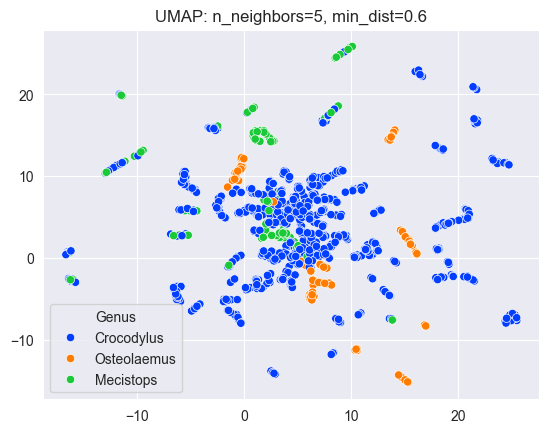

C:\Users\shilo\Documents\Git\Seventh semester\BigData\PythonProject\PR2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



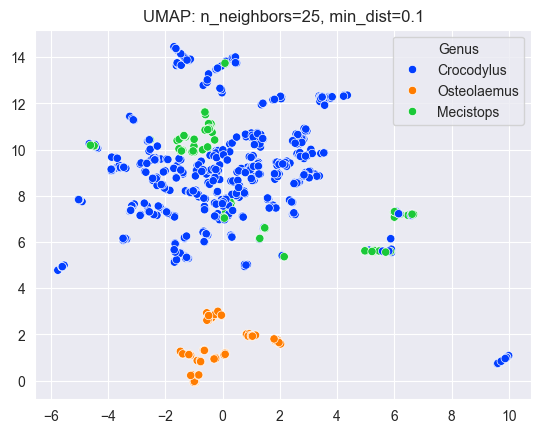

C:\Users\shilo\Documents\Git\Seventh semester\BigData\PythonProject\PR2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



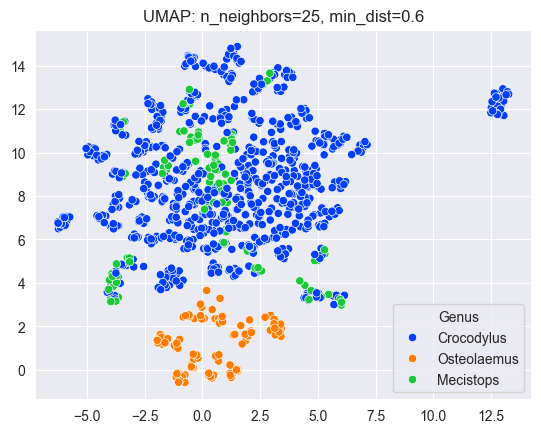

C:\Users\shilo\Documents\Git\Seventh semester\BigData\PythonProject\PR2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



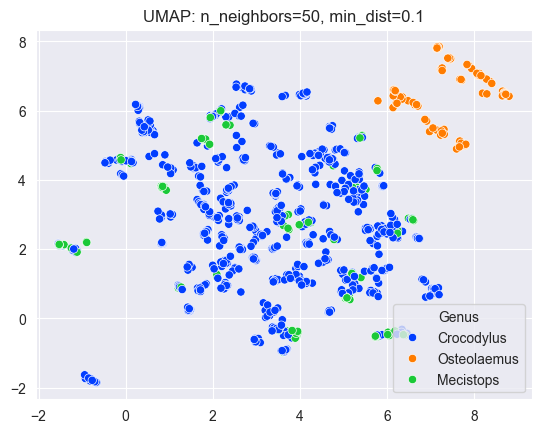

C:\Users\shilo\Documents\Git\Seventh semester\BigData\PythonProject\PR2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



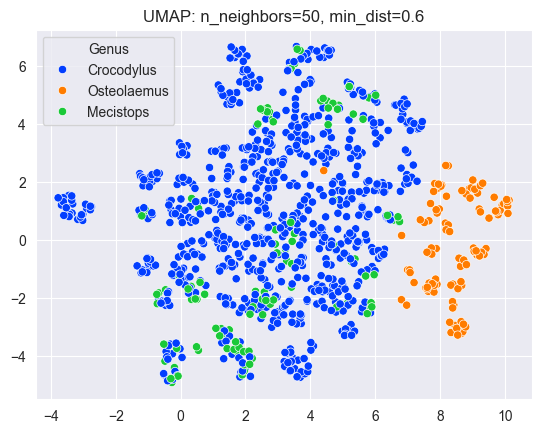

Time taken for UMAP: 23.20 seconds


In [15]:
import pandas as pd
from sklearn import preprocessing
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import time

data = pd.read_csv("crocodile.csv")

features = ["Observed Length (m)", "Observed Weight (kg)", "Age Class", "Sex", "Habitat Type"]
D = pd.get_dummies(data[features], drop_first=True)

scaler = preprocessing.MinMaxScaler()
D = pd.DataFrame(scaler.fit_transform(D), columns=D.columns)

n_n = (5, 25, 50)
m_d = (0.1, 0.6)

start_time_umap = time.time()
for nn in n_n:
    for md in m_d:
        um = umap.UMAP(n_neighbors=nn, min_dist=md, random_state=16).fit_transform(D)

        plt.figure()
        sns.scatterplot(x=um[:, 0], y=um[:, 1], hue=data['Genus'], palette='bright')
        plt.title(f"UMAP: n_neighbors={nn}, min_dist={md}")
        plt.show()
end_time_umap = time.time()
print(f"Time taken for UMAP: {end_time_umap - start_time_umap:.2f} seconds")